# IMPORT REQUIRED LIBRARIES

In [20]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# LOAD DATA

In [2]:
df = pd.read_csv("/content/creditcard.csv")

# CHECK SHAPE OF DATA

In [3]:
df.shape

(284807, 31)

# COUNT RECORDS IN EACH CLASS

In [4]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


# DEFINE FEATURES AND TARGET

In [6]:
X = df.drop("Class", axis=1)
y = df["Class"]

# SPLIT DATA

In [7]:
# Random train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [8]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nClass distribution in y_train:")
print(pd.Series(y_train).value_counts(normalize=True) * 100)

print("\nClass distribution in y_test:")
print(pd.Series(y_test).value_counts(normalize=True) * 100)

X_train shape: (227845, 30)
X_test shape: (56962, 30)
y_train shape: (227845,)
y_test shape: (56962,)

Class distribution in y_train:
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64

Class distribution in y_test:
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


# BALANCE THE DATA (SMOTE)

In [9]:
smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# CHECK DATA DISTRIBUTION AFTER BALANCING

In [10]:
y_train_bal.value_counts()

,count
Class,
0,227451
1,227451


# SCALE DATA

In [12]:
scaler = StandardScaler()
X_train_bal[['Amount','Time']] = scaler.fit_transform(X_train_bal[['Amount','Time']])
X_test[['Amount','Time']] = scaler.transform(X_test[['Amount','Time']])

# BALANCED + SCALED MODEL

In [13]:
# create the model
lr_balanced = LogisticRegression(max_iter=1000)



In [14]:
# fit data
lr_balanced.fit(X_train_bal, y_train_bal)



LogisticRegression(max_iter=1000)

In [16]:
y_pred_balanced = lr_balanced.predict(X_test)

print("BALANCED + SCALED MODEL")
print(classification_report(y_test, y_pred_balanced))

BALANCED + SCALED MODEL
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962



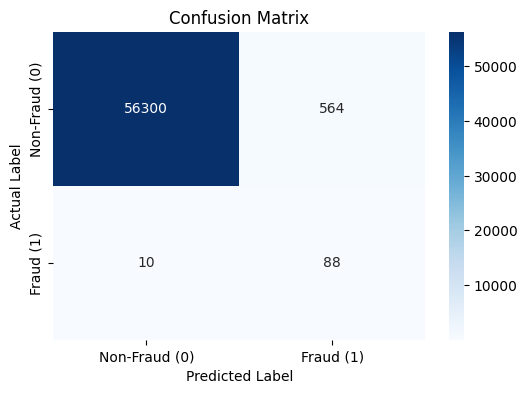

In [21]:
cm = confusion_matrix(y_test, y_pred_balanced)
labels = ["Non-Fraud (0)", "Fraud (1)"]

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

# USING CLASS WEIGHTING

In [27]:
lr_classweights = LogisticRegression(max_iter=5000, class_weight='balanced',solver = "liblinear")



In [28]:
scaler = StandardScaler()
X_train[['Amount','Time']] = scaler.fit_transform(X_train[['Amount','Time']])
X_test[['Amount','Time']] = scaler.transform(X_test[['Amount','Time']])

In [29]:
lr_classweights.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=5000, solver='liblinear')

In [31]:
y_pred_weights = lr_classweights.predict(X_test)

print("BALANCED + SCALED MODEL")
print(classification_report(y_test, y_pred_weights))

BALANCED + SCALED MODEL
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.90      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.93      0.53     56962
weighted avg       1.00      0.96      0.98     56962



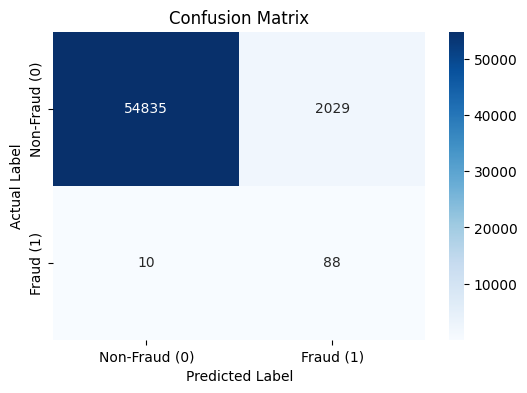

In [33]:
cm = confusion_matrix(y_test, y_pred_weights)
labels = ["Non-Fraud (0)", "Fraud (1)"]

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()